# 01 — Data Quality Check

1. Cek **missing value** per stasiun & per kolom.
2. Cek **distribusi data** (PM2.5, AOD, cuaca).
3. Cek **sinkronisasi waktu** (gap, duplikat tanggal, panjang seri).

source: `Data Penelitian/data gabungan aod cuaca pm2.5/<station>.csv` .

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config as C
from src.data_loader import load_all_stations, missing_value_report

sns.set_theme(style='whitegrid')

## 1. Cek sinkronisasi waktu

In [2]:
raw_dfs = load_all_stations(reindex=False)

rows = []
for name, df in raw_dfs.items():
    rows.append({
        'station': name,
        'rows': len(df),
        'date_min': df[C.DATE_COL].min(),
        'date_max': df[C.DATE_COL].max(),
        'duplicate_dates': df[C.DATE_COL].duplicated().sum(),
        'expected_days': (df[C.DATE_COL].max() - df[C.DATE_COL].min()).days + 1,
    })
df_time = pd.DataFrame(rows)
df_time['gap_days'] = df_time['expected_days'] - df_time['rows']
df_time

,station,rows,date_min,date_max,duplicate_dates,expected_days,gap_days
0,us_embassy_1,1096,2022-01-01,2024-12-31,0,1096,0
1,us_embassy_2,1096,2022-01-01,2024-12-31,0,1096,0
2,jakarta_gbk,1096,2022-01-01,2024-12-31,0,1096,0
3,bundaran_hi,1096,2022-01-01,2024-12-31,0,1096,0
4,kelapa_gading,1096,2022-01-01,2024-12-31,0,1096,0
5,jagakarsa,1096,2022-01-01,2024-12-31,0,1096,0
6,lubang_buaya,1096,2022-01-01,2024-12-31,0,1096,0
7,kebun_jeruk,1096,2022-01-01,2024-12-31,0,1096,0


## 2. Reindex harian, cek missing value

In [3]:
dfs = load_all_stations(reindex=True)
report = missing_value_report(dfs)
report.to_csv(C.METRICS_DIR / 'missing_value_report.csv', index=False)
report

,station,n_rows,missing_ISPU PM2.5,missing_AOD,missing_temp,missing_dew,missing_humidity,missing_precip,missing_windspeed
0,us_embassy_1,1096,102,270,0,0,0,0,0
1,us_embassy_2,1096,260,285,0,0,0,0,0
2,jakarta_gbk,1096,726,291,0,0,0,0,0
3,bundaran_hi,1096,201,291,0,0,0,0,0
4,kelapa_gading,1096,201,246,0,0,0,0,0
5,jagakarsa,1096,201,269,0,0,0,0,0
6,lubang_buaya,1096,201,278,0,0,0,0,0
7,kebun_jeruk,1096,201,292,0,0,0,0,0


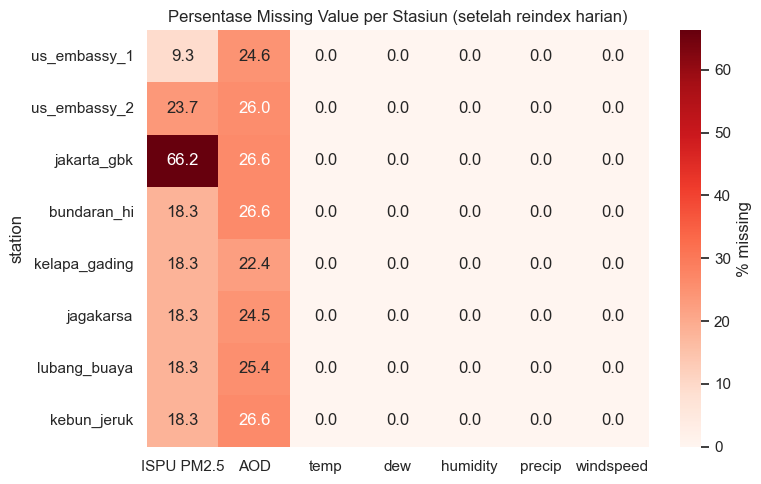

In [4]:
# Visualisasi missing value (heatmap %)
miss_cols = [c for c in report.columns if c.startswith('missing_')]
pct = report.set_index('station')[miss_cols].div(report.set_index('station')['n_rows'], axis=0) * 100
pct.columns = [c.replace('missing_', '') for c in pct.columns]

plt.figure(figsize=(8, 5))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% missing'})
plt.title('Persentase Missing Value per Stasiun (setelah reindex harian)')
plt.tight_layout()
plt.savefig(C.FIG_DIR / '01_missing_pct.png', dpi=120)
plt.show()

## 3. Distribusi PM2.5 dan AOD

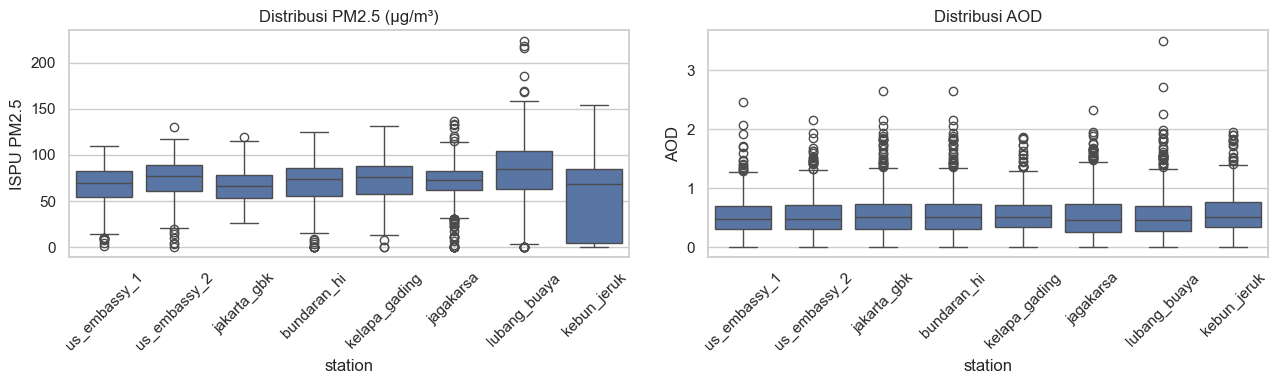

In [5]:
long = []
for name, df in dfs.items():
    sub = df[[C.TARGET, C.AOD_COL]].copy()
    sub['station'] = name
    long.append(sub)
long_df = pd.concat(long, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=long_df, x='station', y=C.TARGET, ax=axes[0])
axes[0].set_title('Distribusi PM2.5 (µg/m³)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=long_df, x='station', y=C.AOD_COL, ax=axes[1])
axes[1].set_title('Distribusi AOD')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(C.FIG_DIR / '01_distribution_pm25_aod.png', dpi=120)
plt.show()

In [6]:
# Statistik deskriptif gabungan
summary = long_df.groupby('station')[[C.TARGET, C.AOD_COL]].describe().round(3)
summary.to_csv(C.METRICS_DIR / 'descriptive_stats.csv')
summary

ISPU PM2.5                                                   \
                   count    mean     std     min     25%     50%      75%   
station                                                                     
bundaran_hi        895.0  70.168  21.521   0.000  55.575  73.500   86.088   
jagakarsa          895.0  71.612  19.450   0.000  62.028  72.611   82.909   
jakarta_gbk        370.0  66.495  19.721  25.867  52.827  65.958   78.681   
kebun_jeruk        895.0  56.499  37.947   0.000   4.611  68.800   84.950   
kelapa_gading      895.0  72.479  20.706   0.000  57.574  75.556   88.250   
lubang_buaya       895.0  83.117  30.335   0.000  62.675  84.476  104.280   
us_embassy_1       994.0  67.645  19.615   0.720  54.091  69.525   82.394   
us_embassy_2       836.0  74.477  20.107   0.298  61.100  76.797   88.563   

                          AOD                                                   
                   max  count   mean    std    min    25%    50%    75%    max  
station                                                                         
bundaran_hi    125.167  805.0  0.567  0.360  0.001  0.311  0.507  0.733  2.646  
jagakarsa      137.167  827.0  0.544  0.368  0.003  0.263  0.468  0.739  2.327  
jakarta_gbk    119.125  805.0  0.567  0.360  0.001  0.311  0.507  0.733  2.646  
kebun_jeruk    153.778  804.0  0.568  0.328  0.007  0.334  0.520  0.759  1.948  
kelapa_gading  131.722  850.0  0.552  0.301  0.011  0.336  0.504  0.720  1.873  
lubang_buaya   223.941  818.0  0.535  0.375  0.010  0.272  0.465  0.703  3.501  
us_embassy_1   109.555  826.0  0.529  0.316  0.005  0.300  0.477  0.696  2.464  
us_embassy_2   129.936  811.0  0.536  0.329  0.006  0.301  0.481  0.708  2.154

## 4. Time-series PM2.5 per stasiun (cek pola & gap)

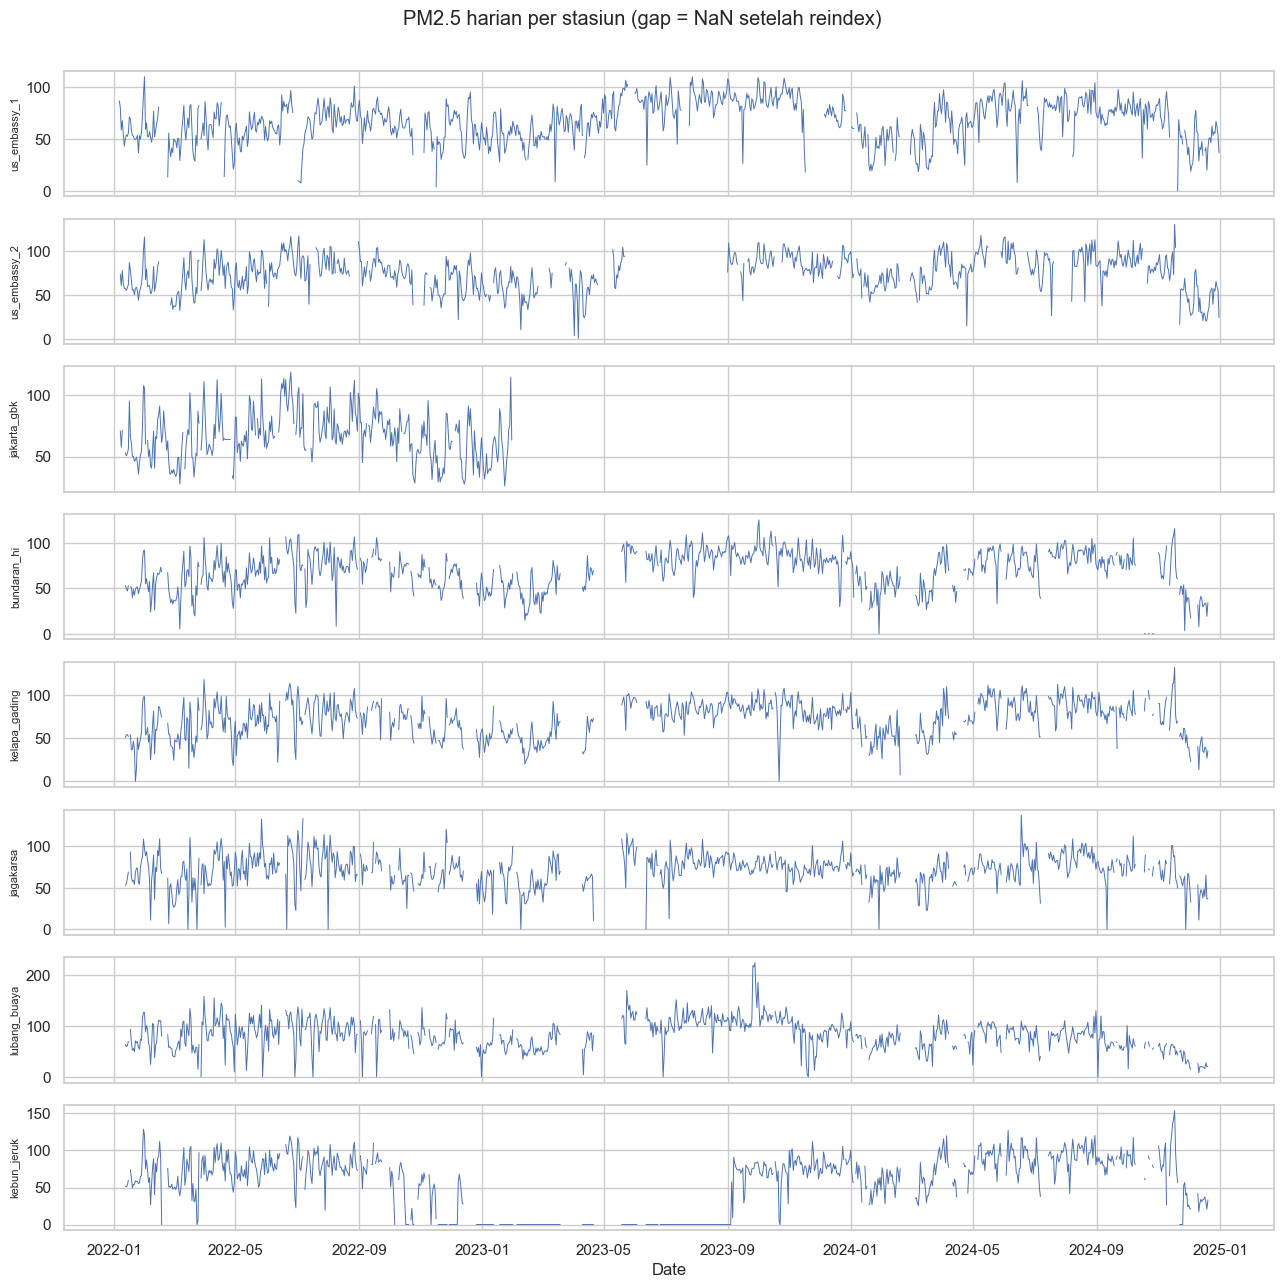

In [7]:
fig, axes = plt.subplots(len(dfs), 1, figsize=(13, 1.6 * len(dfs)), sharex=True)
for ax, (name, df) in zip(axes, dfs.items()):
    ax.plot(df[C.DATE_COL], df[C.TARGET], lw=0.7)
    ax.set_ylabel(name, fontsize=8)
axes[-1].set_xlabel('Date')
fig.suptitle('PM2.5 harian per stasiun (gap = NaN setelah reindex)', y=1.005)
plt.tight_layout()
plt.savefig(C.FIG_DIR / '01_timeseries_pm25.png', dpi=120)
plt.show()

disini

- Jakarta GBK memiliki missing value sangat tinggi pada PM2.5 (sesuai skripsi kak steven, 2023–2024 hilang).jadi akan dikeluarkan dulu dari beberapa eksperimen (`HEALTHY_STATIONS`).
- AOD memiliki ~24–27% missing di semua stasiun, perlu imputasi yang robust.
- Cuaca (Visual Crossing) hampir lengkap (≤ beberapa baris missing).
- Tidaka ada duplikat.